# Neural network estimating the committor of IRE1 in different membrane compositions

In this notebook we train a feed-forward neural network to predict the committor of IRE1 based on the membrane composition using inter monomer distances and properties of the lipid bilayer estimated by a different neural network (see properties_nn.ipynb)

What is done in this notebook (summary):
- Creating training dataset from the AIMMD runs
- Loading in committor references and creating validation dataset 
- Training feed-forward neural network to predict the committor of multiple membrane compositions based on inter monomer distances and membrane properties
- Setup for the search of hyperparameters like number of hidden layers, number of nodes per layer etc.

In [42]:
%load_ext autoreload
import sys
from pathlib import Path
from tqdm import tqdm
import itertools
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler
from matplotlib.colors import Normalize
import pandas as pd

# load custom functions
sys.path.insert(1, '../../functions')
import committor_nn as committor_nn
from functions import mkdir, pkl_load, pkl_save, compute_com_dist
import aimmd_analysis as aimmd_analysis
import properties_nn as properties_nn
from utils import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Definitions

Here we define the path to the AIMMD runs

In [27]:
%autoreload
# Get all AIMMD directories for a system
SYSTEMS = aimmd_analysis.get_paths(f'../../systems/full_elastic_network/**/new_aimmd', key_index=-2, verbose=True)

keys of dictionary:

DOPC100
POPC100
POPE100
POPC90_CHOL10
DIPC80_CHOL20
POPC80_CHOL20
POPC70_CHOL30
POPC80_DIPC20
POPC50_DIPC50
POPC80_DOPC20
POPC60_DOPC40
POPC50_DOPC50
POPC40_DOPC60
POPC20_DOPC80
POPC80_CHOL10_DPPC10
POPC90_DPPC10
DIPC60_CHOL20_DPPC20
POPC80_POPE20
POPC50_POPE50


# Create training dataset

In this section we collect data form the AIMMD runs of 8 membrane compositions for the training of the neural network. For every simulated frame we collect the inter-monomer distances, the shooting results based on the AIMMD path as well as calculate a selection probability which ensures that the different paths (ARA, BRB, RAR, RBR, ARB, BRA) are represented in an equal manner in the training batch.

## Setup

In [68]:
COMPOSITION = ['POPC100',
               'POPC90_CHOL10',
               'POPC80_CHOL20',
               'POPC70_CHOL30',
               'POPC20_DOPC80',
               'POPC50_DOPC50',
               'POPC80_DOPC20',
               'POPC90_DPPC10']

best_model = pkl_load(f'pickles/best_properties_nn_model.h5')
connection_mask = np.load('../../DRMSD_reference/CV_connections/connections_mask.npy')
skip = True

/home/jackel/anaconda3/envs/MET/lib/python3.9/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))


## Calculation

In [11]:
# setup
property_model = properties_nn.Network(output_size =7, **best_model[1])
property_model.load_state_dict(best_model[0])
property_model.to('cuda')

# main loop
for rep, composition in tqdm(enumerate(COMPOSITION), total=len(COMPOSITION)):
    
    # skip already computed datasets
    if os.path.isfile(f'pickles/datasets/{composition}.npz') and skip:
        continue
        
    # import AIMMD params
    current_directory = os.getcwd() 
    os.chdir(SYSTEMS[composition])
    exec(open(Path(f'params.py'), 'r').read())
    os.chdir(current_directory)

    # Load pathensemble
    PATHENSEMBLE = aimmd_analysis.load_pathensemble(states_function,
                                           descriptors_function,
                                           values_function,
                                           directory=SYSTEMS[composition] / 'prun_cluster',
                                           verbose=False,
                                           use_aimmd=True)
    
    # estimate properties of composition with best property nn
    properties = properties_nn.evaluate(property_model, 
                                            [properties_nn.transfer_membrane_comp(composition)])
    
    # extract trainingdata from Pathensemble
    (results,
     descriptors,
     selection_probabilities) = committor_nn.get_trainingsdata(PATHENSEMBLE)

    # add properties to descriptors
    descriptors = np.hstack((descriptors[connection_mask],
                             np.repeat([properties],
                                       len(descriptors), axis=0)))


    # save datasets
    np.savez(f'pickles/datasets/{composition}.npz',
             results=results,
             descriptors=descriptors,
             selection_probabilities=selection_probabilities)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [27:06<00:00, 203.34s/it]


# Creating Validation dataset

In this section we create the committor validation dataset for 5 different membrane compositions. The reference data consists of 30-40 conformations for each membrane composition for which the committor was computed via 30 independent shooting simulations form that conformation. 

## Setup

In [7]:
# setup
best_model = pkl_load(f'pickles/best_properties_nn_model.h5')
connection_mask = np.load('../../DRMSD_reference/CV_connections/connections_mask.npy')
property_model = properties_nn.Network(**best_model[0])
property_model.load_state_dict(best_model[1])
property_model.to('cuda')

def create_descriptors(trajectory:md.core.trajectory.Trajectory, composition):
    global property_model, connection_mask
    distances = committor_nn.get_distances(trajectory, '../../DRMSD_reference/CV_connections/connections.npy')[:, connection_mask]
    properties = properties_nn.evaluate(property_model, [properties_nn.transfer_membrane_comp(composition)])
    properties = np.repeat(np.array([properties]), distances.shape[0], axis=0)
    return np.hstack((distances,
                          properties))

## Calculation

In [8]:
%autoreload
validation = committor_nn.get_validation_dataset(directory             = Path('../../systems/full_elastic_network'),
                                           descriptor_fuction    = create_descriptors,
                                           membrane_compositions = None)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:16<00:00, 15.39s/it]


# Training committor nn

In this section we train an feed-forward neural network to predict the committor of IRE1 in different membrane compositions using inter-monomer distances and properties of the membrane compositions as input. The resulting model is compared to the reference committor of the validation conformations.

## Setup

In [49]:
# Training_parameters
Training_parameters = {'Batch_size'            : pow(2, 14),
                       'Learning_rate'         : 5e-05,
                       'Epochs'                : 10000}

# Neural network parameters
NN_parameters       = {'Hidden_layers'         : [512, 512],
                       'Activation_function'   : [torch.nn.PReLU(512),
                                                  torch.nn.PReLU(512)],
                       'Batch_norm'            : True,
                       'Dropout'               : 0.1}

# sweep name
Parameters_dict     = dict(Training_parameters, **NN_parameters)

In [14]:
%autoreload
# define path
COMPOSITION = ['POPC100',
               'POPC90_CHOL10',
               'POPC80_CHOL20',
               'POPC70_CHOL30',
               'POPC20_DOPC80',
               'POPC50_DOPC50',
               'POPC80_DOPC20',
               'POPC90_DPPC10']

path_to_datasets = [f'pickles/datasets/{composition}.h5' for composition in COMPOSITION]

# Division of the trainins set in training and testing based on the first 5 pathensembles
train_dataset = committor_nn.ZMatrix(data_paths = path_to_datasets,
                               membrane_compositions = None
                               )

print(f"Batch size: {Parameters_dict['Batch_size']}")
print(f"Training set size: {len(train_dataset)}")
print(f"Descriptors size: {train_dataset.descriptors.shape[-1]}")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:46<00:00, 43.32s/it]

Batch size: 65536
Training set size: 3793844
Descriptors size: 791


In [17]:
# Fit only on training data
scaler = StandardScaler()
scaler.fit(train_dataset.descriptors)

train_dataset.descriptors = scaler.transform(train_dataset.descriptors)
pkl_save('pickles/scaler_committor_nn.h5')

## Calculation

The following training procedire will produce: 

- `best.pt` which contains the best model generated during training. The best model is selected based on the test loss
- `network.txt` which contains base parameters and architecture of the network
- `test_losses.npy` which contains the evolution of the test loss during training
- `train_losses.npy` which contains the evolution of the train loss during training

Training: , Epoch=9999, Train loss=0.216, validation loss=0.765, best validation loss=0.597, scales=9.45                                    


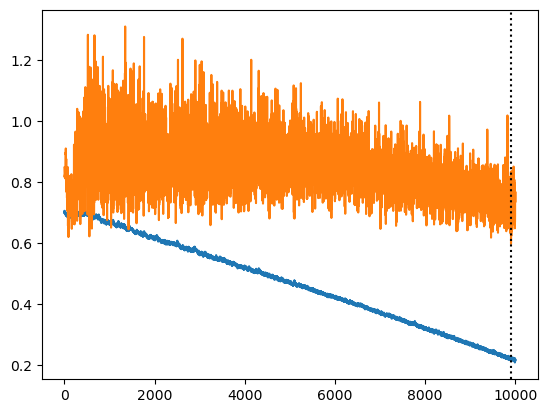

In [63]:
%autoreload
# Run training and save the network

network = committor_nn.Network(n_features=train_dataset.descriptors.shape[-1],
                         hidden_layers=Parameters_dict['Hidden_layers'],
                         activation=Parameters_dict['Activation_function'],
                         batch_norm=Parameters_dict['Batch_norm'], 
                         dropout=Parameters_dict['Dropout'])
network.to('cuda')

losses, validation_losses, scales = committor_nn.train(network,
                                                    train_dataset,
                                                    validation,
                                                    batch_size = Parameters_dict['Batch_size'],
                                                    epochs=Parameters_dict['Epochs'],
                                                    lr=Parameters_dict['Learning_rate'],
                                                    save_to=f'pickles/committor_models/best_model',
                                                    verbose=True,
                                                        scaler=scaler)

pkl_save(f'pickles/committor_models/current.h5', [network.input_parameters, network.state_dict()])
plt.plot(losses)
plt.plot(validation_losses)
plt.axvline(np.argmin(validation_losses), linestyle=':', color='black')

## Validation

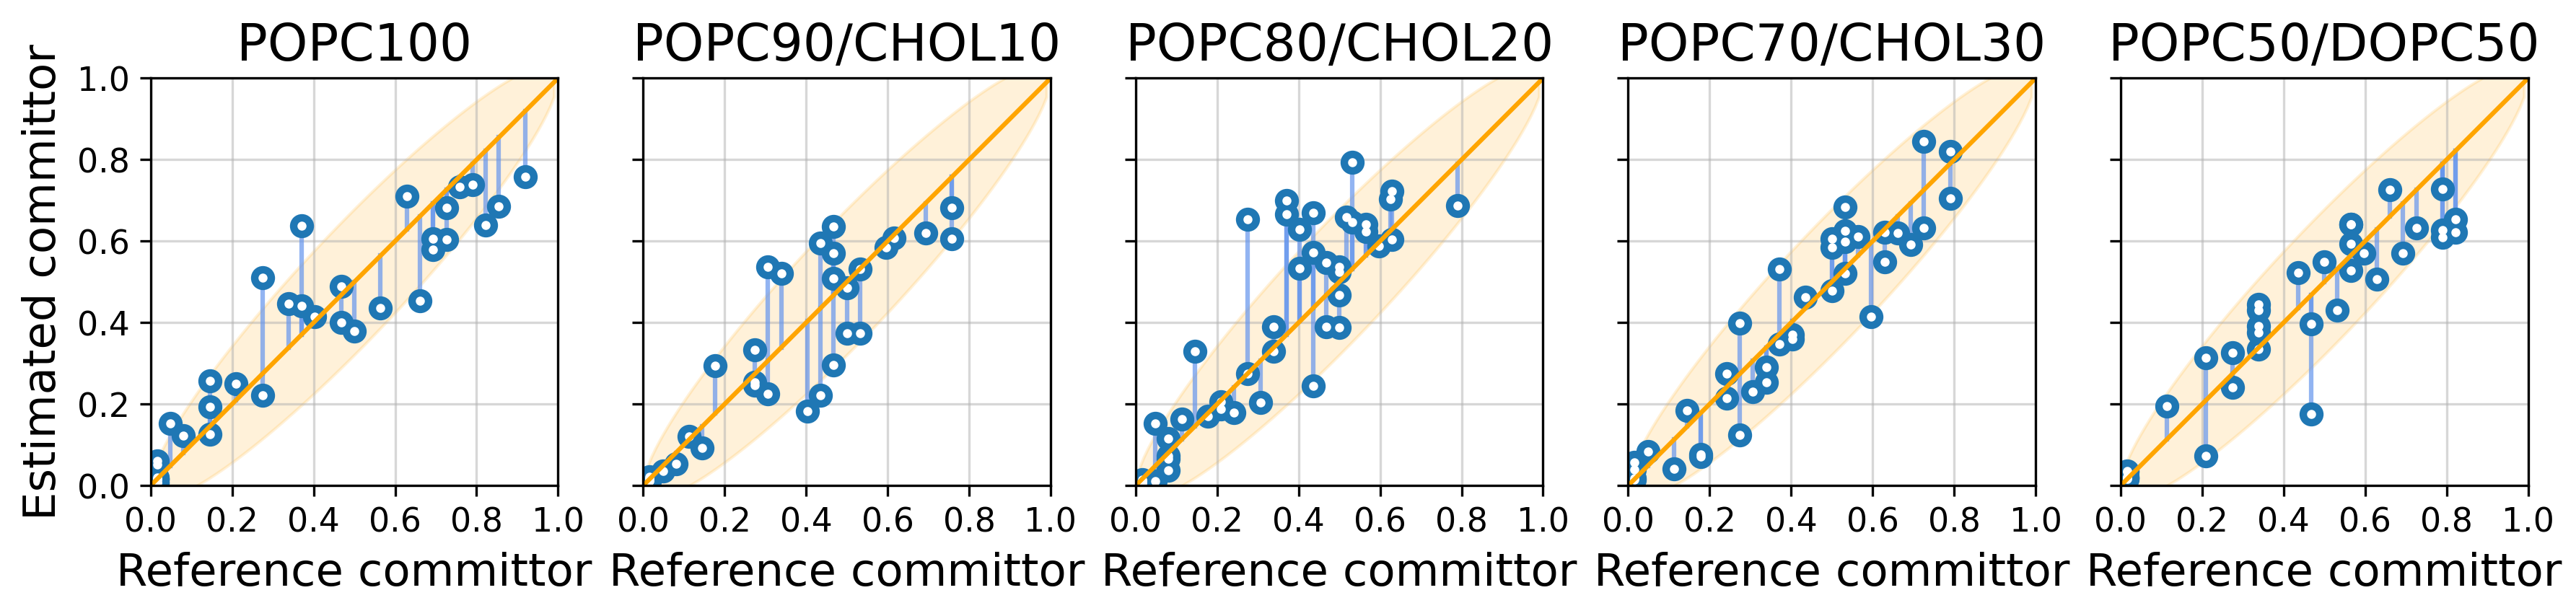

In [73]:
# Create a 4x4 grid of subplots (16 total)
fig, axes = plt.subplots(1, 5, figsize=(12, 3), dpi=300, sharey=True)
network.to(device='cpu')

COMPOSITION = ['POPC100', 'POPC90_CHOL10', 'POPC80_CHOL20', 'POPC70_CHOL30', 'POPC50_DOPC50']

# Loop through each subplot and plot something
for num, composition  in enumerate(COMPOSITION):
    
    # load network
    best_model = pkl_load(f'pickles/committor_models/committor_nn.h5')
    network = committor_nn.Network(**best_model[0])
    network.load_state_dict(best_model[1])
    network.to('cuda')
    
    # axes
    ax = axes[num]
    name = '/'.join(composition.split('_'))
    
    # calculating error points
    conformation, reference = validation[composition]
    estimate = expit(evaluate(network, scaler.transform(np.squeeze(np.array(conformation)))))
    error_list = []
    for i in np.arange(len(estimate)):
#         error = np.abs(reference[i]-estimate[i])/(
#             reference[i] if reference[i] < .5 else 1 - reference[i])
        error = np.abs(reference[i]-estimate[i])
        error_list.append(error)
    
    # plotting lines 
    for i in np.arange(len(reference)):
        ax.axvline(reference[i], estimate[i], reference[i], alpha=0.7, color='cornflowerblue')
        
    # computing 95% confidence interval
    variance_result = np.asanyarray([1.96*np.sqrt(((i*(1-i))/30)) for i in np.arange(0,1,0.01)])
    ax.fill_between(np.arange(0,1,0.01),
                    np.arange(0,1,0.01)+variance_result,
                    np.arange(0,1,0.01)-variance_result,
                    color='orange',
                    alpha=0.15)
    
    # plotting data
    ax.plot(reference, estimate, linestyle='', marker = 'o', markersize=7)
    ax.plot(reference, estimate, linestyle='', marker = 'o', color='w', markersize=2)
    ax.plot(np.linspace(0,1, 10), np.linspace(0,1, 10), color='orange')

    
    # plot label etc.
    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    if num == 0:
        ax.set_ylabel('Estimated committor', fontsize=15)
    ax.set_xlabel('Reference committor', fontsize=15)
    ax.set_title(name, fontsize= 17)
    ax.grid(alpha=0.5)
    ax.tick_params(axis='both', which='major', labelsize=11)
    ax.set_aspect('equal')
    ax.set_xticks(np.arange(0, 1.1, 0.2))
    
    # error text
    coef = np.polyfit(reference,estimate,1)
    correction = np.abs(1-coef[0]) + np.abs(0-coef[1])/2
    error = np.mean(error_list) + correction
#     ax.text(0.72,0.02, f'{np.round(error, 3)}', fontsize=14, transform = ax.transAxes)
    poly1d_fn = np.poly1d(coef)
#     ax.plot([0, 1], poly1d_fn([0,1]), linestyle=':', color='black')

fig.tight_layout()
plt.savefig(f'plots/committor_performance.png', bbox_inches='tight')
plt.show()

In [ ]:
pkl_save('pickles/committor_models/committor_nn.h5', [network.input_parameters, network.state_dict()])

# Hyperparameter search

This section is a setup for hyperparameter search optimizing the amount of hidden layers, nodes per layer, activation function and dropout

## Setup

In [82]:
%autoreload
# define path
COMPOSITION = ['POPC100',
               'POPC90_CHOL10',
               'POPC80_CHOL20',
               'POPC70_CHOL30',
               'POPC20_DOPC80',
               'POPC50_DOPC50',
               'POPC80_DOPC20',
               'POPC90_DPPC10']

path_to_datasets = [f'pickles/datasets/{composition}.h5' for composition in COMPOSITION]

# Division of the trainins set in training and testing based on the first 5 pathensembles
dataset = committor_nn.ZMatrix(data_paths = path_to_datasets,
                               membrane_compositions = None)
validation = pkl_load('pickles/validation_committor_nn.h5')
save_path = mkdir('pickles/hyper_parameter_searches')
sweep_name = 'sweep_hidden_layer'

# hidden layer combinations
temp = [32, 64, 128, 256, 512]
temp_list = []
temp_list = (list(itertools.product(temp)) + 
             list(itertools.product(temp, temp)) + 
             list(itertools.product(temp, temp, temp)))

In [83]:
# Definitions
continue_from_previous_run = True


# Training_parameters
Training_parameters = {'Batch_size'            : [100000],
                       'Learning_rate'         : [2.5e-5],
                       'Epochs'                : [30000],
                       'Replica'               : [0]}

# Neural network parameters
NN_parameters       = {'Hidden_layers'         : temp_list,
                       'Activation_function'   : [torch.nn.ReLU],
                       'Batch_norm'            : [True],
                       'Dropout'               : [0.05]}


# sweep name
Parameters_dict     = dict(Training_parameters, **NN_parameters)#, **other_parameters)

In [84]:
parameter_names, input_parameters = zip(*Parameters_dict.items())
parameter_lists = list(itertools.product(*input_parameters))
print(f'Number of parameter combinations: {len(parameter_lists)}')

Number of parameter combinations: 258


## Calculation

In [ ]:
%autoreload
mkdir(f'{save_path}/{sweep_name}')
if continue_from_previous_run:
    try:
        results_list = pkl_load(str(save_path / sweep_name))
        recover = [str(trial[0]) for trial in results_list]
    except:
        results_list = []
        recover = []
    
for num, parameters in enumerate(tqdm(parameter_lists)):
    parameter_dict = dict(zip(parameter_names, parameters))
    
    if parameter_dict['Activation_function'] == torch.nn.PReLU:
        activation_functions = []
        for i in parameter_dict['Hidden_layers']:
            activation_functions.append(parameter_dict['Activation_function'](i))
        parameter_dict['Activation_function'] = activation_functions
        
    if parameter_dict['Activation_function'] == torch.nn.ReLU:
        activation_functions = []
        for i in parameter_dict['Hidden_layers']:
            activation_functions.append(parameter_dict['Activation_function']())
        parameter_dict['Activation_function'] = activation_functions

    
    # check if these parameters where already done
    if str(parameter_dict) in recover:
        continue
    
    train_dataset = committor_nn.ZMatrix(dataset,
                                   equilibriumA=parameter_dict['EquilibriumA_frames'],
                                   equilibriumB=parameter_dict['EquilibriumB_frames'],
                                   verbose=False)
    

    # Run training and save the network
    network = committor_nn.Network(n_features=train_dataset.shooting_descriptors.shape[-1],
                             hidden_layers=parameter_dict['Hidden_layers'],
                             activation=parameter_dict['Activation_function'],
                             batch_norm=parameter_dict['Batch_norm'],
                             dropout=parameter_dict['Dropout'])
    
    network, optimizer, device, dtype = committor_nn.prepare_network(network,
                                                               lr=parameter_dict['Learning_rate'], 
                                                               optimizer=None,
                                                               cuda=True,
                                                               save_path=None)
    
    train_losses, test_losses, best_model = committor_nn.train(network,
                                                         parameter_dict['Epochs'],
                                                         parameter_dict['Batch_size'],
                                                         optimizer,
                                                         train_dataset,
                                                         validation,
                                                         device,
                                                         dtype,
                                                         parameter_dict['Randomize_equilibrium'],
                                                         stop=50,
                                                         max_epochs_with_no_improvement=100,
                                                         verbose=False,
                                                         save_to=f'{save_path}/{sweep_name}/{num}.h5')

    results_list.append({'parameters':parameter_dict,
                         'best_model':best_model,
                         'training_losses':train_losses,
                         'validation_losses':test_losses})
    
    pkl_save(save_path / f'{sweep_name}.h5' ,results_list)

 57%|████████████████████████████████████████████████████                                        | 146/258 [105:51:46<72:25:11, 2327.78s/it]

## Analysis

In [ ]:
# Definition
diff_array = np.flip(np.asanyarray(temp), axis=0)
diff_array = np.flip(np.asanyarray([i[1] for i in stuff]), axis=0)
# lowest_mean = np.where(diff_array[:, 0].astype(float) == np.min(diff_array[:, 0].astype(float)))
# lowest_std = np.where(diff_array[:, 1].astype(float) == np.min(diff_array[:, 1].astype(float)))

# plot
plt.figure(figsize=(6, len(diff_array)/4), dpi=500)

# line with the lowest mean
plt.axvline(diff_array[-1, 0].astype(float),
            color='red',
            linestyle=':',
            label=f'Lowest error: {np.round(diff_array[-1, 0].astype(float), 4)}')

# plot model values
plt.errorbar(diff_array[:, 0].astype(float),
             np.arange(0, len(diff_array[:, 0].astype(float))),
             xerr=diff_array[:, 1].astype(float),
             linestyle='',
             marker='o',
             color='royalblue',
             alpha=0.8)

plt.errorbar(diff_array[:, 0].astype(float),
             np.arange(0, len(diff_array[:, 0].astype(float))),
             linestyle='',
             marker='o',
             color='blue')

# labels
plt.yticks(np.arange(0, len(diff_array[:, 0])), labels=np.flip(np.asanyarray([i[0] for i in stuff])), rotation=0)
plt.xlabel('Model error', fontsize= 12)
plt.title(f'Best models')
plt.grid()
plt.tight_layout()
plt.legend(numpoints = 1, markerscale=0.5, fontsize=9)
plt.xlim([-0.02, 2.5])

# save option
# plt.savefig(f'Best_models.pdf')
plt.show()

Plot 2

In [ ]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
fig = plt.figure(figsize=[15,5], dpi=300)
ax = fig.subplots(1, 6, sharey=True)
for i in np.arange(6):
    data = matrix_dict[str(first_layer_list[i])]
    img = ax[i].imshow(data,cmap='magma_r', vmax=0.09, vmin=0.0863)

    ax[i].set_xticks([0, 1, 2, 3, 4, 5, 6])
    ax[i].set_yticks([0, 1, 2, 3, 4, 5, 6])
    ax[i].tick_params()
    ax[i].set_xticklabels([0, 32, 64, 128, 256, 512, 1024],rotation=90)#, ha="right", rotation_mode="anchor")
    ax[i].set_yticklabels([0, 32, 64, 128, 256, 512, 1024],rotation=0)
    ax[i].set_title(f'First layer: {first_layer_list[i]}', fontsize=10)
    ax[i].set_xlabel('Third layer', fontsize=10)
ax[0].set_ylabel('Second layer', fontsize=10)

cbar = fig.colorbar(img, ax=ax, pad=0.01, shrink=0.38, fraction=0.1, aspect=12).set_label('Error')
# plt.savefig('combined_neural_network/hyperparameter_search_hiddenlayers.png')
plt.show()

# Committor to dRMSD

## Setup

In [16]:
# Definition
COMPOSITIONS = ['POPC100', 'POPC90_CHOL10', 'POPC80_CHOL20', 'POPC70_CHOL30']
connections_mask = np.load('../../DRMSD_reference/CV_connections/connections_mask.npy')
connections_ref = np.load('../../DRMSD_reference/CV_connections/connections_ref.npy')
connection_mask_drmsd = np.arange(len(connections_mask))
scaler = pkl_load('pickles/scaler_committor_nn.h5')

# load property model
best_model = pkl_load(f'pickles/best_properties_nn_model.h5')
property_model = properties_nn.Network(output_size =7, **best_model[1])
property_model.load_state_dict(best_model[0])
property_model.to('cuda')

Network(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): PReLU(num_parameters=512)
    (3): Dropout(p=0.05, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): PReLU(num_parameters=512)
    (7): Dropout(p=0.05, inplace=False)
    (8): Linear(in_features=512, out_features=512, bias=True)
    (9): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): PReLU(num_parameters=512)
    (11): Dropout(p=0.05, inplace=False)
    (12): Linear(in_features=512, out_features=7, bias=True)
  )
)

### Optional cell

compute this cell only if you want to calculate the dRMSD using the reference we used for the state A definition

In [22]:
# changes dRMSD parameters
connections = np.load('../../DRMSD_reference/CV_connections/connections.npy')
connections_ref = np.load('../../DRMSD_reference/CV_connections/stateA_connections.npy')
connection_mask_drmsd = []
for i in connections:
    if np.max(np.sum(connections_ref[:, :2] == i, axis=1)) == 2:
        connection_mask_drmsd.append(True)
    else:
        connection_mask_drmsd.append(False)
connection_mask_drmsd = np.asanyarray(connection_mask_drmsd)

## Calculation

In [23]:
%autoreload
save_folder = mkdir('pickles/committor_to_drmsd')
for composition in tqdm(COMPOSITIONS):
    
    # get params
    current_directory = os.getcwd() 
    os.chdir(SYSTEMS[composition])
    exec(open(Path(f'params.py'), 'r').read())
    os.chdir(current_directory)

    # Load pathensemble
    PATHENSEMBLE = aimmd_analysis.load_pathensemble(states_function,
                                           descriptors_function,
                                           values_function,
                                           directory=SYSTEMS[composition] / 'prun_cluster',
                                           verbose=False,
                                           use_aimmd=True)
    
    # loading in combined nn
    best_model = pkl_load('pickles/committor_models/committor_nn.h5')
    network_combined_nn = committor_nn.Network(**best_model[0])
    network_combined_nn.load_state_dict(best_model[1])
    network_combined_nn.to('cuda')
    
    # estimate properties
    propetries = properties_nn.evaluate(property_model, [properties_nn.transfer_membrane_comp(composition)])
    
    # calculate dRMSD and estimate committor
    descriptors        = PATHENSEMBLE.frame_descriptors
    drmsd              = aimmd_analysis.dRMSD_from_descriptors(descriptors[:, connection_mask_drmsd], connections_ref)
    input_features     = np.hstack((descriptors[:,connections_mask], np.repeat(np.array([propetries]), len(descriptors), axis=0)))
    committor          = properties_nn.evaluate(network_combined_nn, scaler.transform(input_features))
    
    # save 
    pkl_save(Path(save_folder) / f'{composition}_state_A.h5', [drmsd, committor])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [07:15<00:00, 108.91s/it]


## Plots

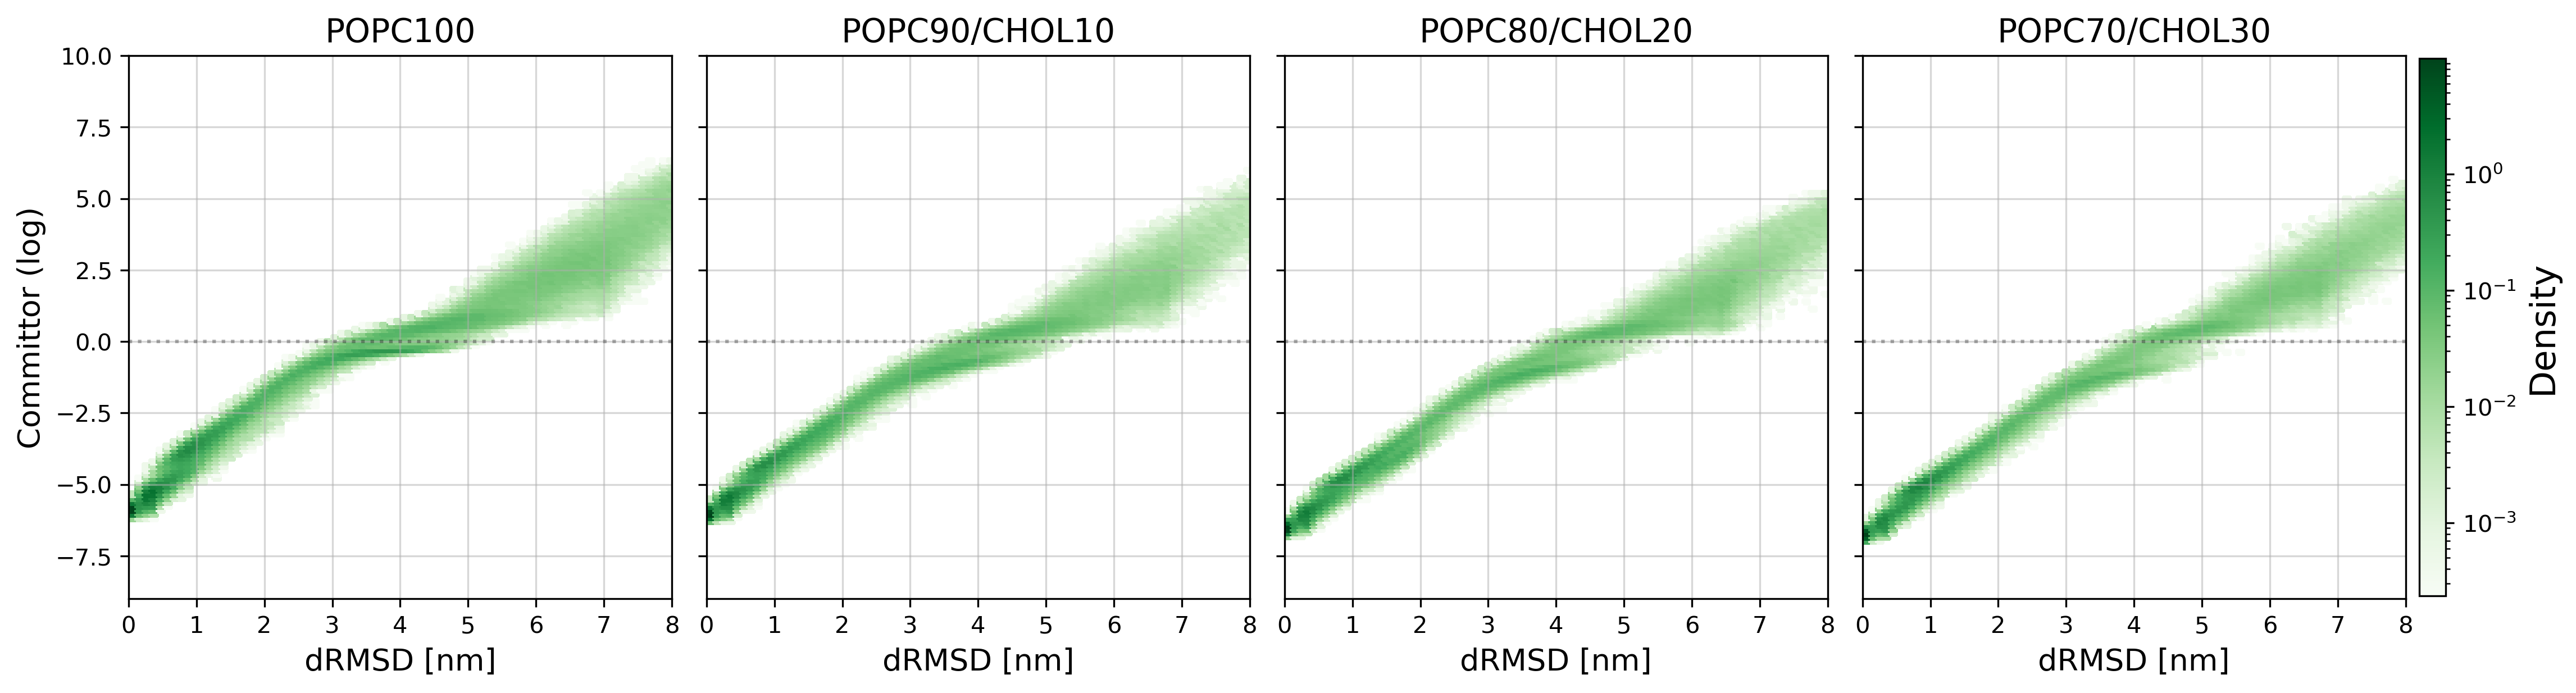

In [25]:
# Create a 4x4 grid of subplots (16 total)
fig, axes = plt.subplots(1, 4, figsize=(17, 4), dpi=300, sharey=True, sharex=True)

# Loop through each subplot and plot something
for num, composition  in enumerate(COMPOSITIONS):
    
    #loading in the data and defining axes
    name = '/'.join(composition.split('_'))
    drmsd, committor = pkl_load(f'pickles/committor_to_drmsd/{composition}_state_A.h5')
    ax1 = axes[num]
    
    # doing 2d histogramm for both committor models
    data = ax1.hist2d(drmsd, committor, bins=100, density=True, cmap='Greens', norm='log', edgecolor='face')

    ## axis
    ax1.set_title(name, fontsize=14)
    ax1.set_ylim(-9, 10)
    ax1.set_xlim(0, 8)
    ax1.set_aspect(8/19)
    ax1.grid(alpha=0.5)
    ax1.axhline(0, linestyle=':', color='black', alpha=0.3)
#     ax1.axvline(0.5, linestyle=':', color='black', alpha=0.5)
    ax1.set_xlabel('dRMSD [nm]', fontsize=13)
    ax1.set_xticks(np.arange(0, 9))
    if num == 0:
        ax1.set_ylabel('Committor (log)', fontsize=13)

fig.tight_layout()

if num == 3:
    cbar = fig.colorbar(data[-1], ax=axes, pad=0.005, shrink=0.99)
    cbar.set_label(label='Density', fontsize=15)
    
plt.savefig('plots/committor_to_drmsd_stateA.pdf', bbox_inches='tight')

# Importance analysis

We perform a feature-importance analysis to understand which inputs the model relies on most for its predictions. For each feature, we replace its values with random samples drawn from a uniform distribution bounded by the feature’s minimum and maximum values in the validation set. We repeat this process 200 times for every feature and measure how much the model’s loss deviates from the original loss. The magnitude of this change indicates the importance of that feature.

## Setup

In [28]:
%autoreload
# load validation data
validation = pkl_load('pickles/validation_committor_nn.h5')
scaler = pkl_load('pickles/scaler_committor_nn.h5')

# put descriptors and results from all membrane compositions in one array
descriptors = []
reference = []
for key in validation:
    descriptors.append(validation[key][0])
    reference.append(validation[key][1])
descriptors = scaler.transform(np.squeeze(np.concatenate(descriptors)))
reference = np.concatenate(reference)

In [29]:
# load in best model
best_model = pkl_load('pickles/committor_models/committor_nn.h5')
network = committor_nn.Network(**best_model[0])
network.load_state_dict(best_model[1])
network.to(device='cpu')

Network(
  (net): Sequential(
    (0): Linear(in_features=791, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): PReLU(num_parameters=512)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=512, out_features=512, bias=True)
    (5): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): PReLU(num_parameters=512)
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=512, out_features=1, bias=True)
  )
)

In [30]:
# get an array of descriptions for every feature
connection_mask = np.load('../../DRMSD_reference/CV_connections/connections_mask.npy')
connections = np.load('../../DRMSD_reference/CV_connections/connections.npy')
distances = []
for i in connections[connection_mask]:
    distances.append(f'a{i[0]}-a{i[1]}')
membrane_properties = np.load('pickles/datasets/properties_nn_dataset.npz')['membrane_properties'][[0,1,2,3,5,6,7]]
descriptions = np.append(np.asanyarray(distances), membrane_properties)

## Evaluation of feature importance

In [35]:
%autoreload
# get test loss on original partition 
original_loss = committor_nn.test_network(network, descriptors, reference)
original_loss

0.07898077735371327

In [ ]:
save_folder = mkdir('pickles/importance_analysis')
iterations = 200

# initialize all losses for every feature variation
hipr_losses = np.zeros(descriptors.shape[1])

# for each single feature
for feature in tqdm(np.arange(descriptors.shape[1])): 
    
    # store losses for the current feature evaluation
    feature_losses = []
    for i in range(iterations): 
        
        temp_descriptors = descriptors.copy()
        
        # get max and min value of the ith feature
        max_feature = np.max(temp_descriptors[:, feature])
        min_feature = np.min(temp_descriptors[:, feature])
        
        # generate uniform distribution of the ith feature
        new_ith_features_val = np.random.uniform(min_feature, max_feature, len(temp_descriptors))
        
        # replace the ith feature with the new generated values
        temp_descriptors[:, feature] = new_ith_features_val
        
        
        # calculate loss and and store it
        feature_losses.append(committor_nn.test_network(network, temp_descriptors, reference))
    
    # final loss for the current feature is the average of all losses for this iteration cycle
    hipr_losses[feature] = np.mean(feature_losses)

# save hipr_losses 
np.save(f'{save_folder}/validation_losses_best_model.npy', hipr_losses)

In [36]:
# load hipr_losses
hipr_losses = np.load('pickles/importance_analysis/validation_losses_best_model.npy')

# calculate differences with respect to the original loss and sort
differences = hipr_losses - original_loss
differences = [-value if value < 0 else value for value in differences]
sorted_indices = np.argsort(hipr_losses - original_loss)[::-1]

In [37]:
# get list of the 4 most important features based on index
most_important_features = sorted_indices[:10]

# get dictionary with index and difference in loss for the 5 most important features
most_important_features_dict = {i: differences[i] for i in most_important_features}

# print most_important_features to list in a file
# the order here is only important for questions related to nomenclature that are established in the downstream pipeline
with open('pickles/importance_analysis/most_important_features.txt', 'w') as f:
    f.write(f"{most_important_features[0]}\n{most_important_features[2]}\n{most_important_features[1]}\n{most_important_features[3]}\n")

In [43]:
# get list of the features based on index
most_important_features = np.argsort(differences)[::-1]

# get dictionary with index and difference in loss for all the features
most_important_features_dict = {i: differences[i] for i in most_important_features}
# sort by value in decreasing order
most_important_features_dict = dict(sorted(most_important_features_dict.items(), key=lambda item: item[1], reverse=True))

# normalize the diffferences value so that the highest is 1 and the lowest is 0
norm = Normalize(vmin=min(most_important_features_dict.values()), vmax=max(most_important_features_dict.values()))
norm_differences = {k: norm(v) for k, v in most_important_features_dict.items()}

# convert to dataframe and save to tsv
df = pd.DataFrame.from_dict(norm_differences, orient='index', columns=['normalized_importance'])
df.index.name = 'feature'
df.to_csv("pickles/importance_analysis/importance_features.tsv", sep='\t', index=True, header=True)

## Plots

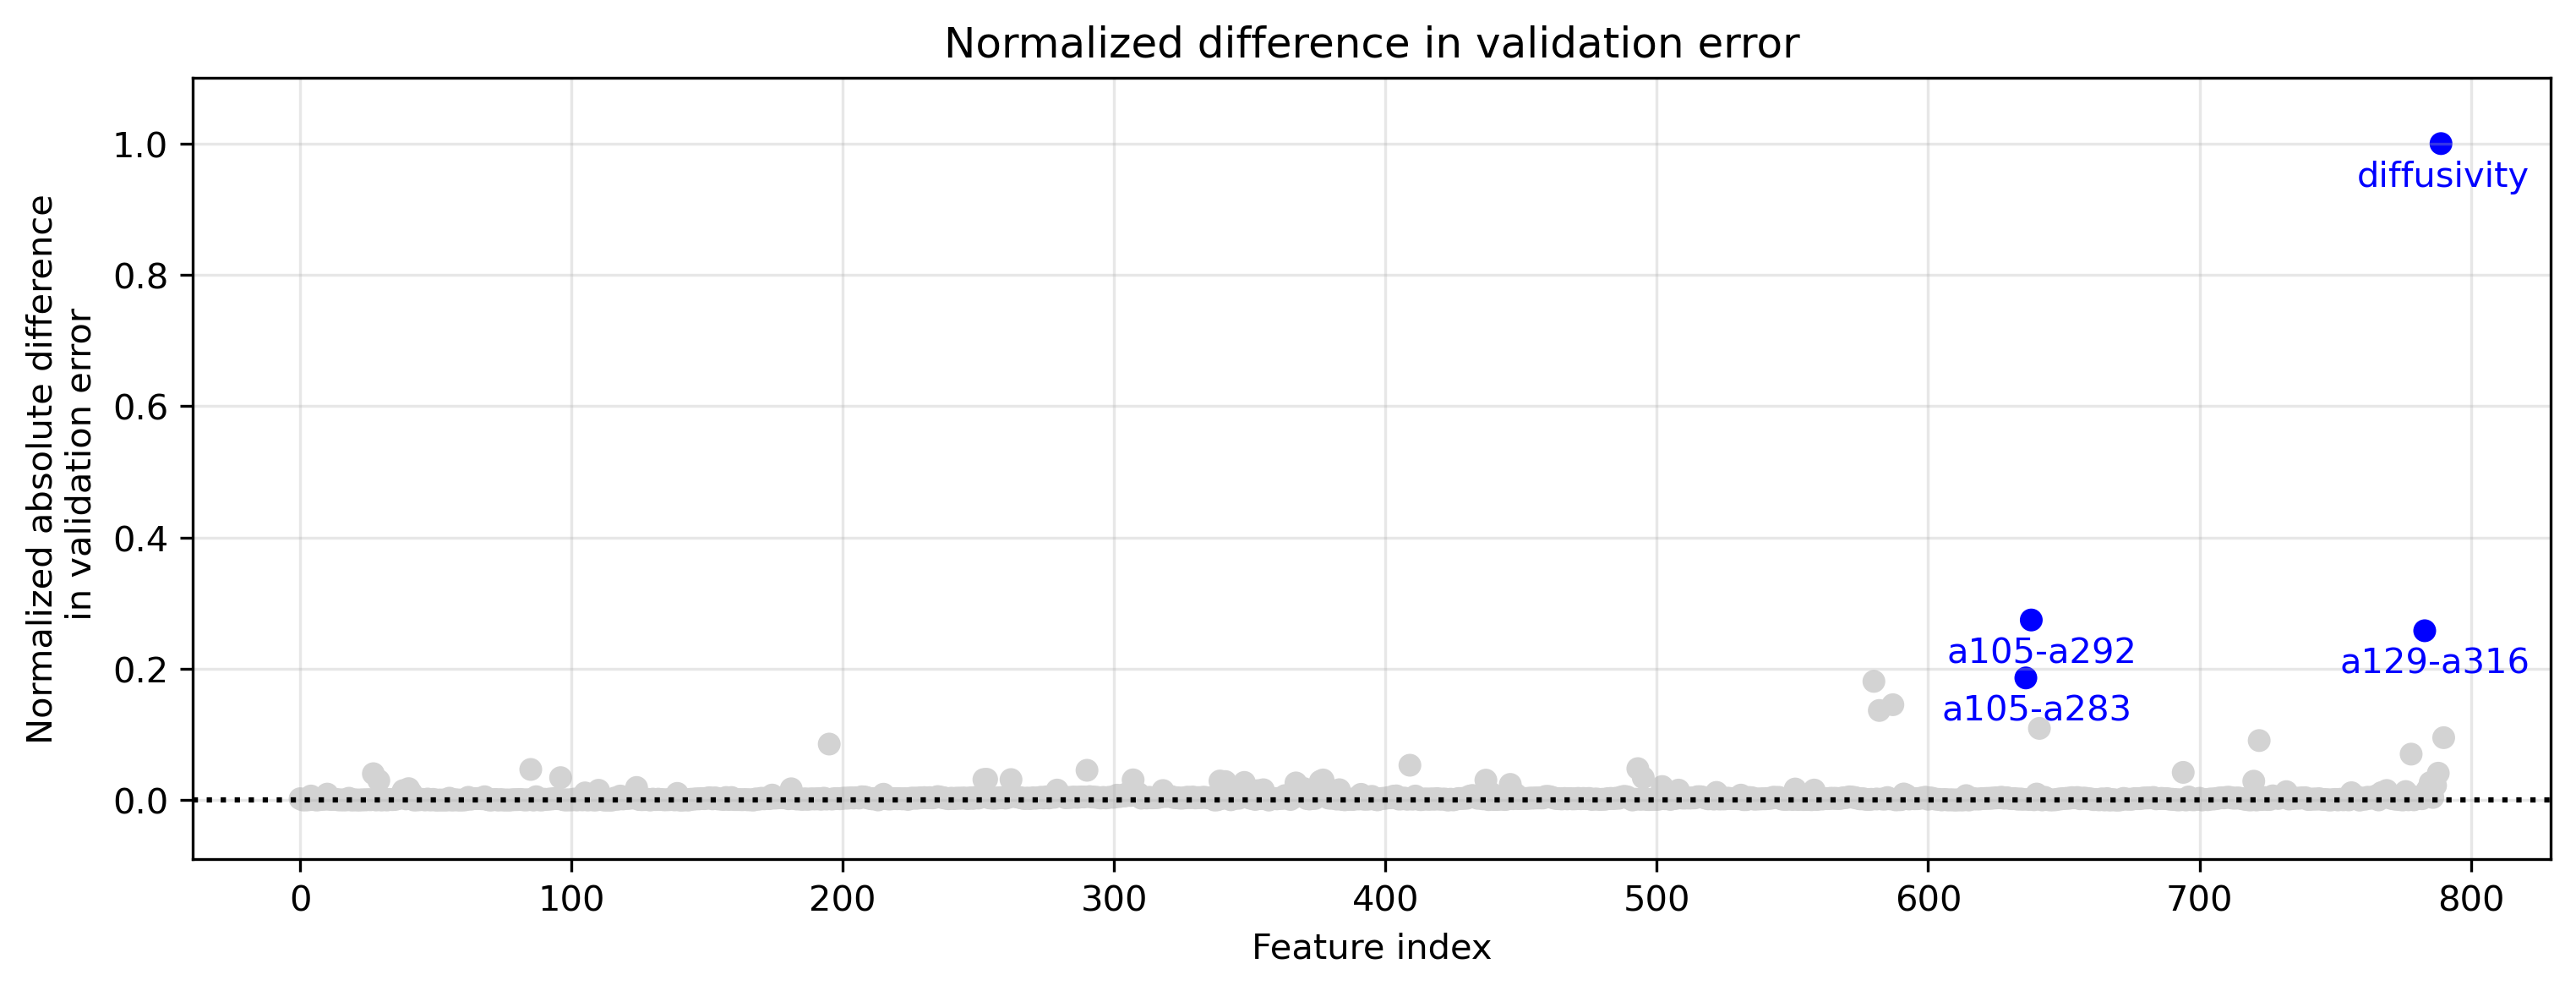

In [44]:
# Define feature range and filter indices and values within the range
feature_start, feature_end = 784, 791
feature_start, feature_end = 0, 791
filtered_indices = [i for i in range(feature_start, feature_end) if i < len(differences)]
filtered_differences = {i: norm_differences[i] for i in filtered_indices}

# Create the scatter plot
plt.figure(figsize=(12, 4), dpi=300)

# Generate scatter colors dynamically for the filtered range
scatter_colors = ['lightgrey'] * len(differences)   # Default color
for feature in most_important_features[:4]:
    scatter_colors[feature] = 'blue'
    plt.annotate(descriptions[feature], (feature, norm_differences[feature]),
                 xytext=(-100,-50),
                 textcoords='offset pixels',
                 color='blue')



# Plot only for filtered features
plt.scatter(filtered_indices, [filtered_differences[i] for i in filtered_indices], 
            color=[scatter_colors[i] for i in filtered_indices], s=30)
plt.axhline(0, linestyle=':', color='black')

plt.xlabel('Feature index')
plt.ylabel('Normalized absolute difference\n in validation error')
plt.title('Normalized difference in validation error')
plt.ylim(-0.09, 1.1)
plt.grid(alpha=0.3)

# Save figure
plt.savefig(f'plots/importance_analysis_all.png', bbox_inches='tight')

## Visualization

In [ ]:
ref = md.load('../../DRMSD_reference/ref.gro')

In [ ]:
# visualize structure and connections
index = 3
show_structure = nv.show_mdtraj(ref)
show_structure.add_spacefill(radius_type="vdw",
                             selection=[connections[connection_mask][most_important_features[1:][index]][0]],
                             color='red', opacity=1)
show_structure.add_spacefill(radius_type="vdw",
                             selection=[connections[connection_mask][most_important_features[1:][index]][1]],
                             color='blue', opacity=1)
# show_structure.add_spacefill(radius_type="vdw", selection=[60+187], color='blue', opacity=1)
show_structure.center()
show_structure